# 02 — Model Training and Group Audit

This notebook trains two audit models: Model A includes sex and race, while Model B removes sex from the feature set and uses sex only as an auditing variable.


## 1. Install packages

For anyone trying to reproduce thsi notebook:

Run this cell if you are using Google Colab or a fresh local environment.

If you are running locally and already installed the requirements, you can skip this cell.

In [1]:
!pip install -q folktables shap lime scikit-learn pandas numpy matplotlib

## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from folktables import ACSDataSource, ACSEmployment

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [3]:
from pathlib import Path

# To save the figures
FIGURE_DIR = Path("../figures")
if not FIGURE_DIR.parent.exists():
    FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

POSTER_BLUE = "#0393DB"
POSTER_ORANGE = "#F26B21"
POSTER_GREEN = "#2E8B45"
POSTER_RED = "#D13F35"
POSTER_WHITE = "white"


## 3. Load the Folktables ACSEmployment dataset

The dataset has been downloaded directly through the `folktables` package and uses California as the default state.

In [4]:
# Load 2024 ACS person-level data for California

import pandas as pd
from folktables import ACSDataSource

data_source = ACSDataSource(
    survey_year="2024",
    horizon="1-Year",
    survey="person"
)

acs_data = data_source.get_data(states=["CA"], download=True)

# 2024 ACS
feature_map = {
    "AGEP": "age",
    "SCHL": "education",
    "MAR": "marital_status",
    "RELSHIPP": "relationship",
    "DIS": "disability",
    "ESP": "employment_status_parent",
    "CIT": "citizenship",
    "MIG": "mobility_status",
    "MIL": "military_service",
    "ANC": "ancestry",
    "NATIVITY": "nativity",
    "DEAR": "hearing_difficulty",
    "DEYE": "vision_difficulty",
    "DREM": "cognitive_difficulty",
    "SEX": "sex",
    "RAC1P": "race"
}

needed_cols = list(feature_map.keys()) + ["ESR"]

df = acs_data[needed_cols].copy()
df = df.rename(columns=feature_map)

# Convert ACS character-coded variables to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Restrict to working-age range for a labor-market analysis
df = df[(df["age"] >= 16) & (df["age"] <= 90)].copy()

# ESR = Employment Status Recode.
# Census codes:
# 1 = Civilian employed, at work
# 2 = Civilian employed, with a job but not at work
# 3 = Unemployed
# 4 = Armed forces, at work
# 5 = Armed forces, with a job but not at work
# 6 = Not in labor force
#
# For a broader "employed or has job" target:
df["employment"] = df["ESR"].isin([1, 2, 4, 5]).astype(int)

# Original Folktables ACSEmployment target:
# df["employment"] = (df["ESR"] == 1).astype(int)

df = df.drop(columns=["ESR"])

df.head()

,age,education,marital_status,relationship,disability,employment_status_parent,citizenship,mobility_status,military_service,ancestry,nativity,hearing_difficulty,vision_difficulty,cognitive_difficulty,sex,race,employment
0,45,7.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,9,0
1,45,14.0,3,37,1,NaN,1,3.0,4.0,1,1,2,2,1.0,1,3,0
2,21,20.0,5,38,2,NaN,1,1.0,4.0,1,1,2,2,2.0,2,8,1
3,28,18.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,8,0
4,19,18.0,5,38,2,NaN,1,3.0,4.0,1,1,2,2,2.0,2,6,0


## 5. Add readable labels for key auditing variables

For the this analysis, the variables of interest are **sex** and **race**.

The ACS sex variable is binary in this task:
- `1 = Male`
- `2 = Female`

Please note that binary encoding does not capture the full range of gender identity and can create a false hierarchy.

In [5]:
sex_map = {
    1: "Male",
    2: "Female"
}

race_map = {
    1: "White",
    2: "Black",
    3: "American Indian",
    4: "Alaska Native",
    5: "American Indian/Alaska Native - specified tribe",
    6: "Asian",
    7: "Native Hawaiian/Pacific Islander",
    8: "Other",
    9: "Two or more races"
}

citizenship_map = {
    1: "Born in U.S.",
    2: "Born in Puerto Rico / U.S. Island Areas",
    3: "Born abroad to U.S. parents",
    4: "U.S. citizen by naturalization",
    5: "Not a U.S. citizen"
}

df["sex_label"] = df["sex"].map(sex_map)
df["race_label"] = df["race"].map(race_map)
df["citizenship_label"] = df["citizenship"].map(citizenship_map)

df[["sex", "sex_label", "race", "race_label", "citizenship", "citizenship_label", "employment"]].head()

,sex,sex_label,race,race_label,citizenship,citizenship_label,employment
0,1,Male,9,Two or more races,1,Born in U.S.,0
1,1,Male,3,American Indian,1,Born in U.S.,0
2,2,Female,8,Other,1,Born in U.S.,1
3,1,Male,8,Other,1,Born in U.S.,0
4,2,Female,6,Asian,1,Born in U.S.,0


## 6. Basic data inspection

Taking a look at the data shape, missing values, and target distribution.

In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nEmployment distribution:")
display(df["employment"].value_counts().rename(index={0: "Not employed", 1: "Employed"}).to_frame("count"))
display(df["employment"].value_counts(normalize=True).rename(index={0: "Not employed", 1: "Employed"}).to_frame("proportion"))

Shape: (328738, 20)

Columns:
['age', 'education', 'marital_status', 'relationship', 'disability', 'employment_status_parent', 'citizenship', 'mobility_status', 'military_service', 'ancestry', 'nativity', 'hearing_difficulty', 'vision_difficulty', 'cognitive_difficulty', 'sex', 'race', 'employment', 'sex_label', 'race_label', 'citizenship_label']

Missing values:


,missing_count
employment_status_parent,319774
military_service,5001
age,0
education,0
relationship,0
marital_status,0
citizenship,0
disability,0
mobility_status,0
ancestry,0



Employment distribution:


,count
employment,
Employed,187819
Not employed,140919


,proportion
employment,
Employed,0.571333
Not employed,0.428667


## 7. Baseline employment rates by sex and race

Descriptive view of the historical/social pattern in the data.

> Please note: The model is not learning from a neutral world. It is learning from data generated within existing labor-market structures.

In [7]:
sex_rates = (
    df.groupby("sex_label")["employment"]
      .agg(n="count", actual_employment_rate="mean")
      .sort_values("actual_employment_rate", ascending=False)
)

race_rates = (
    df.groupby("race_label")["employment"]
      .agg(n="count", actual_employment_rate="mean")
      .sort_values("actual_employment_rate", ascending=False)
)

display(sex_rates)
display(race_rates)

,n,actual_employment_rate
sex_label,,
Male,161841,0.610500
Female,166897,0.533353


,n,actual_employment_rate
race_label,,
Asian,59717,0.608135
Other,52469,0.605958
Two or more races,54256,0.598072
American Indian,4444,0.592034
Native Hawaiian/Pacific Islander,1099,0.583258
American Indian/Alaska Native - specified tribe,967,0.556360
White,140942,0.541201
Black,14813,0.483427
Alaska Native,31,0.354839


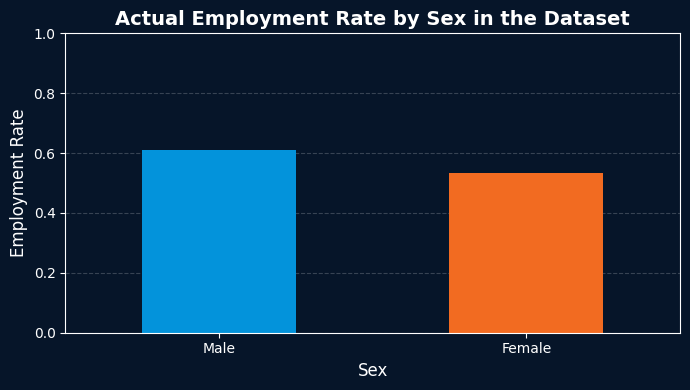

In [8]:
# Setting a transparent background and white text for poster visualization

color_map = {
    "Male": "#0393DB",
    "Female": "#F26B21"
}

bar_colors = [color_map.get(label, "#999999") for label in sex_rates.index]

POSTER_BG = "#061529"
fig, ax = plt.subplots(figsize=(7, 4), facecolor=POSTER_BG)
ax.set_facecolor(POSTER_BG)

sex_rates["actual_employment_rate"].plot(
    kind="bar",
    ax=ax,
    color=bar_colors
)

# Text color
ax.set_title("Actual Employment Rate by Sex in the Dataset", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Sex", color="white", fontsize=12)
ax.set_ylabel("Employment Rate", color="white", fontsize=12)

# Tick colors
ax.tick_params(axis="x", colors="white", rotation=0)
ax.tick_params(axis="y", colors="white")

# Axis/spine colors
for spine in ax.spines.values():
    spine.set_color("white")

# Grid for readability
ax.grid(axis="y", color="white", alpha=0.20, linestyle="--")
ax.set_axisbelow(True)


plt.ylim(0, 1)
plt.tight_layout()

# Save as transparent PNG for PowerPoint/poster
plt.savefig(
    FIGURE_DIR / "actual_employment_by_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 8. Prepare modeling data

Please note that you need to increase `MAX_ROWS` if you want a larger analysis. Otherwise, reduce it if the notebook is slow.

In [9]:
MAX_ROWS = 60000

if len(df) > MAX_ROWS:
    df_model = (
        df.groupby("employment", group_keys=False)
          .apply(lambda x: x.sample(
              n=min(len(x), max(1, int(MAX_ROWS * len(x) / len(df)))),
              random_state=RANDOM_STATE
          ))
          .sample(frac=1, random_state=RANDOM_STATE)
          .copy()
    )
else:
    df_model = df.copy()

print("Modeling dataset shape:", df_model.shape)
display(df_model["employment"].value_counts(normalize=True).to_frame("proportion"))

Modeling dataset shape: (59999, 20)


,proportion
employment,
1,0.571343
0,0.428657


## 9. Define features

This first model includes sex and race so we can audit how the model uses sensitive attributes.

A second model will be trained that removes sex to examine whether gendered prediction gaps remain through proxy variables.

In [10]:
numeric_features = ["age", "education"]

categorical_features_with_sex = [
    "marital_status",
    "relationship",
    "disability",
    "employment_status_parent",
    "citizenship_label",
    "mobility_status",
    "military_service",
    "ancestry",
    "nativity",
    "hearing_difficulty",
    "vision_difficulty",
    "cognitive_difficulty",
    "sex_label",
    "race_label"
]

features_with_sex = numeric_features + categorical_features_with_sex

target_col = "employment"

model_data = df_model[features_with_sex + [target_col]].copy()

# Treating coded ACS fields as categories
for col in categorical_features_with_sex:
    model_data[col] = model_data[col].astype(str)

X = model_data[features_with_sex]
y = model_data[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (47999, 16)
Test shape: (12000, 16)


## 10. Helper functions


In [11]:
def make_onehot_encoder():
    """
    Handles scikit-learn version differences.
    Newer versions use sparse_output; older versions use sparse.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(numeric_cols, categorical_cols):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    classifier = RandomForestClassifier(
        n_estimators=150,
        max_depth=9,
        min_samples_leaf=25,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    return model


def clean_feature_name(name):
    """Make transformed feature names easier to read in plots."""
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    name = name.replace("_", " ")
    return name


def transform_to_dataframe(model, X_input):
    """Apply the model preprocessor and return a dense DataFrame with readable feature names."""
    preprocessor = model.named_steps["preprocessor"]
    transformed = preprocessor.transform(X_input)

    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    feature_names = [clean_feature_name(n) for n in preprocessor.get_feature_names_out()]
    return pd.DataFrame(transformed, columns=feature_names, index=X_input.index)


def summarize_group_predictions(model, X_input, y_true, group_series, group_name="group"):
    """Summarize actual and predicted outcomes by a demographic group."""
    proba = model.predict_proba(X_input)[:, 1]
    pred = (proba >= 0.50).astype(int)

    results = pd.DataFrame({
        group_name: group_series.values,
        "actual": np.array(y_true),
        "predicted": pred,
        "predicted_probability": proba
    }, index=X_input.index)

    summary = (
        results.groupby(group_name)
        .agg(
            n=("actual", "size"),
            actual_employment_rate=("actual", "mean"),
            predicted_employment_rate=("predicted", "mean"),
            mean_predicted_probability=("predicted_probability", "mean")
        )
        .sort_values("predicted_employment_rate", ascending=False)
    )

    return summary, results


def get_positive_class_shap_values(explainer, X_transformed_df):
    """Return SHAP values for the positive class across SHAP versions."""
    raw_values = explainer.shap_values(X_transformed_df, check_additivity=False)

    if isinstance(raw_values, list):
        shap_values = raw_values[1]
    elif hasattr(raw_values, "ndim") and raw_values.ndim == 3:
        shap_values = raw_values[:, :, 1]
    else:
        shap_values = raw_values

    return shap_values


def get_positive_class_base_value(explainer):
    """Return expected/base value for the positive class."""
    base_value = explainer.expected_value

    if isinstance(base_value, (list, np.ndarray)) and np.array(base_value).ndim > 0:
        return base_value[1]
    return base_value


def disparate_impact_ratio(summary_table, protected_group="Female", reference_group="Male", rate_col="predicted_employment_rate"):
    """
    Compute a simple disparate impact ratio:
    protected group selection rate / reference group selection rate.
    """
    if protected_group not in summary_table.index or reference_group not in summary_table.index:
        return np.nan

    ref_rate = summary_table.loc[reference_group, rate_col]
    protected_rate = summary_table.loc[protected_group, rate_col]

    if ref_rate == 0:
        return np.nan

    return protected_rate / ref_rate

## 11. Train Model A: includes sex and race

Please note that this model is not meant to be a deployable hiring system. It is used purely for auditing.

The purpose is to gain insight into:

> What the model learns when sensitive attributes and historically patterned variables are included

In [12]:
model_with_sex = build_pipeline(numeric_features, categorical_features_with_sex)
model_with_sex.fit(X_train, y_train)

y_pred = model_with_sex.predict(X_test)
y_proba = model_with_sex.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not employed", "Employed"]))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7763

Classification report:
              precision    recall  f1-score   support

Not employed       0.77      0.69      0.73      5144
    Employed       0.78      0.84      0.81      6856

    accuracy                           0.78     12000
   macro avg       0.77      0.77      0.77     12000
weighted avg       0.78      0.78      0.77     12000


Confusion matrix:
[[3549 1595]
 [1089 5767]]


## 12. Predicted employment rates by sex

This table compares actual employment rates, predicted employment rates, and average predicted probabilities by sex.

It is important to note that a gap here does not automatically prove discrimination. It shows that the model is reproducing group-patterned differences in the data and requires further investigation.

In [13]:
sex_summary_with_sex, sex_results_with_sex = summarize_group_predictions(
    model_with_sex,
    X_test,
    y_test,
    X_test["sex_label"],
    group_name="sex"
)

display(sex_summary_with_sex)

di_with_sex = disparate_impact_ratio(sex_summary_with_sex, protected_group="Female", reference_group="Male")
print(f"Disparate impact ratio, Female / Male predicted employment rate: {di_with_sex:.3f}")

,n,actual_employment_rate,predicted_employment_rate,mean_predicted_probability
sex,,,,
Male,5908,0.611544,0.630162,0.544851
Female,6092,0.532337,0.597341,0.492298


Disparate impact ratio, Female / Male predicted employment rate: 0.948


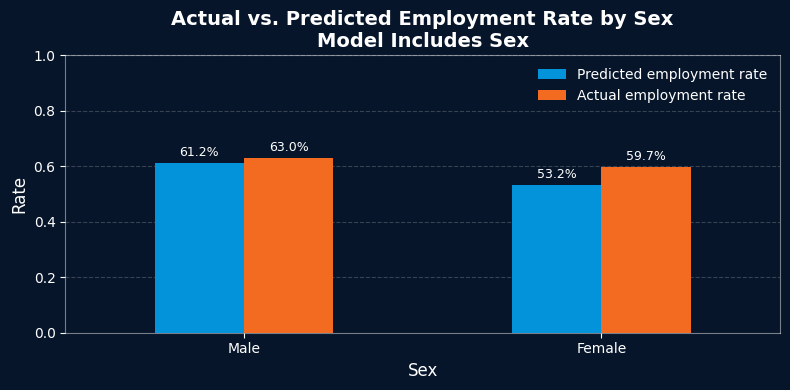

In [14]:
# This visualization is formatted for the poster presentation

# Poster colors
POSTER_BG = "#061529"
actual_color = "#0393DB"     # blue
predicted_color = "#F26B21"  # orange

fig, ax = plt.subplots(figsize=(8, 4), facecolor=POSTER_BG)
ax.set_facecolor(POSTER_BG)

sex_summary_with_sex[["actual_employment_rate", "predicted_employment_rate"]].plot(
    kind="bar",
    ax=ax,
    color=[actual_color, predicted_color]
)

# Title and labels
ax.set_title(
    "Actual vs. Predicted Employment Rate by Sex\nModel Includes Sex",
    color="white",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Sex", color="white", fontsize=12)
ax.set_ylabel("Rate", color="white", fontsize=12)

# Axis/tick formatting
ax.tick_params(axis="x", colors="white", rotation=0)
ax.tick_params(axis="y", colors="white")

for spine in ax.spines.values():
    spine.set_color("white")
    spine.set_alpha(0.45)

# Grid
ax.grid(axis="y", color="white", alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

# Legend formatting
legend = ax.legend(
    ["Predicted employment rate", "Actual employment rate"],
    frameon=False,
    fontsize=10
)

for text in legend.get_texts():
    text.set_color("white")

# add percentage labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height()*100:.1f}%" for v in container],
        color="white",
        fontsize=9,
        padding=3
    )

plt.ylim(0, 1)
plt.tight_layout()

# Save transparent PNG for PowerPoint
plt.savefig(
    FIGURE_DIR / "actual_vs_predicted_by_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 13. Intersectional view: predicted employment by sex and race

This table gives a more nuanced view than sex alone.

For a presentation on biased algorithmic decision-making, this matters because gender does not operate in isolation. Gendered labor-market inequality often intersects with race, disability, citizenship, age, and other social structures.

In [15]:
intersection_results = pd.DataFrame({
    "sex": X_test["sex_label"].values,
    "race": X_test["race_label"].values,
    "actual": y_test.values,
    "predicted": y_pred,
    "predicted_probability": y_proba
}, index=X_test.index)

intersection_summary = (
    intersection_results
    .groupby(["sex", "race"])
    .agg(
        n=("actual", "size"),
        actual_employment_rate=("actual", "mean"),
        predicted_employment_rate=("predicted", "mean"),
        mean_predicted_probability=("predicted_probability", "mean")
    )
    .query("n >= 100")
    .sort_values("predicted_employment_rate", ascending=False)
)

display(intersection_summary)

n  actual_employment_rate  predicted_employment_rate  mean_predicted_probability
sex    race                                                                                                  
Male   Other               955                0.637696                   0.707853                    0.563831
       Asian              1022                0.650685                   0.683953                    0.589952
Female Other               952                0.546218                   0.671218                    0.506105
Male   Two or more races   974                0.629363                   0.668378                    0.557525
Female Asian              1230                0.569106                   0.662602                    0.521610
       Two or more races   967                0.573940                   0.632885                    0.502817
Male   White              2563                0.591494                   0.576668                    0.522708
       Black               256                0.500000                   0.531250                    0.477622
Female Black               258                0.461240                   0.527132                    0.452777
       White              2575                0.500194                   0.526602                    0.470675

## 18. Train Model B: remove sex from the model

Removing sex from the model is not enough to guarantee fairness as a model's inductive bias can still learn bias from the proxy variables.

This section trains a second model that excludes sex but still evaluates outcomes by sex. If gaps remain, that suggests other variables may function as **proxies** for gendered opportunity structures.

In [16]:
categorical_features_no_sex = [c for c in categorical_features_with_sex if c != "sex_label"]
features_no_sex = numeric_features + categorical_features_no_sex

model_data_no_sex = df_model[features_no_sex + ["sex_label", target_col]].copy()

for col in categorical_features_no_sex:
    model_data_no_sex[col] = model_data_no_sex[col].astype(str)

X_no_sex = model_data_no_sex[features_no_sex]
y_no_sex = model_data_no_sex[target_col].astype(int)

X_train_no_sex, X_test_no_sex, y_train_no_sex, y_test_no_sex = train_test_split(
    X_no_sex,
    y_no_sex,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_no_sex
)

model_no_sex = build_pipeline(numeric_features, categorical_features_no_sex)
model_no_sex.fit(X_train_no_sex, y_train_no_sex)

y_pred_no_sex = model_no_sex.predict(X_test_no_sex)

print("Accuracy without sex:", round(accuracy_score(y_test_no_sex, y_pred_no_sex), 4))
print("\nClassification report:")
print(classification_report(y_test_no_sex, y_pred_no_sex, target_names=["Not employed", "Employed"]))

Accuracy without sex: 0.7742

Classification report:
              precision    recall  f1-score   support

Not employed       0.77      0.67      0.72      5144
    Employed       0.77      0.85      0.81      6856

    accuracy                           0.77     12000
   macro avg       0.77      0.76      0.76     12000
weighted avg       0.77      0.77      0.77     12000



## 19. Does the prediction gap remain after removing sex?

Sex has been removed from the model features, but it can still be used as an **auditing variable** to compare outcomes.

This is the key biased algorithmic decision-making point:

> Bias can persist through proxy variables even when a protected attribute is removed.

In [17]:
sex_group_no_sex = df_model.loc[X_test_no_sex.index, "sex_label"]

sex_summary_no_sex, sex_results_no_sex = summarize_group_predictions(
    model_no_sex,
    X_test_no_sex,
    y_test_no_sex,
    sex_group_no_sex,
    group_name="sex"
)

display(sex_summary_no_sex)

di_no_sex = disparate_impact_ratio(sex_summary_no_sex, protected_group="Female", reference_group="Male")
print(f"Disparate impact ratio, Female / Male predicted employment rate, no-sex model: {di_no_sex:.3f}")

,n,actual_employment_rate,predicted_employment_rate,mean_predicted_probability
sex,,,,
Male,5908,0.611544,0.635071,0.518687
Female,6092,0.532337,0.625082,0.515610


Disparate impact ratio, Female / Male predicted employment rate, no-sex model: 0.984


,Model A: includes sex,Model B: excludes sex
sex,,
Male,0.630162,0.635071
Female,0.597341,0.625082


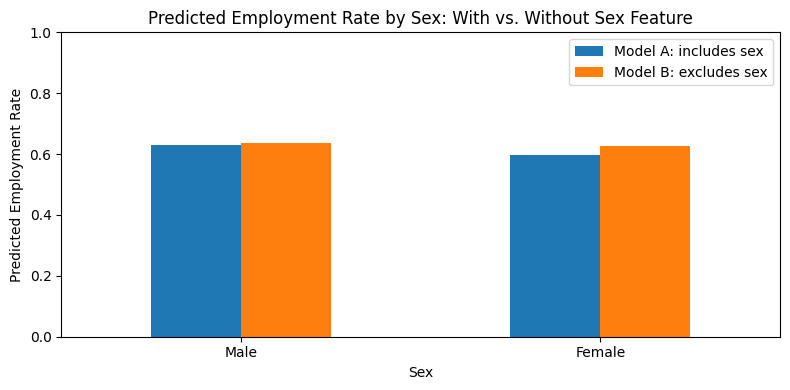

In [18]:
comparison = pd.concat(
    {
        "Model A: includes sex": sex_summary_with_sex["predicted_employment_rate"],
        "Model B: excludes sex": sex_summary_no_sex["predicted_employment_rate"]
    },
    axis=1
)

display(comparison)

ax = comparison.plot(kind="bar", figsize=(8, 4))
ax.set_title("Predicted Employment Rate by Sex: With vs. Without Sex Feature")
ax.set_xlabel("Sex")
ax.set_ylabel("Predicted Employment Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Model A: includes sex,Model B: excludes sex
sex,,
Male,0.630162,0.635071
Female,0.597341,0.625082


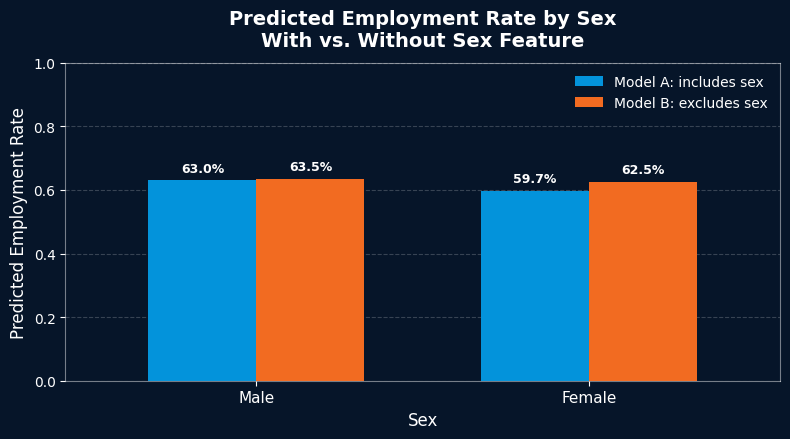

In [19]:
import matplotlib.pyplot as plt

# comparison of prediction rates with and without sex for poster
comparison = pd.concat(
    {
        "Model A: includes sex": sex_summary_with_sex["predicted_employment_rate"],
        "Model B: excludes sex": sex_summary_no_sex["predicted_employment_rate"]
    },
    axis=1
)

display(comparison)

# Poster preview settings
POSTER_BG = "#061529"      # dark preview background only
POSTER_BLUE = "#0393DB"
POSTER_ORANGE = "#F26B21"
POSTER_WHITE = "white"

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=POSTER_BG)
ax.set_facecolor(POSTER_BG)

comparison.plot(
    kind="bar",
    ax=ax,
    color=[POSTER_BLUE, POSTER_ORANGE],
    width=0.65
)

ax.set_title(
    "Predicted Employment Rate by Sex\nWith vs. Without Sex Feature",
    color=POSTER_WHITE,
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Sex", color=POSTER_WHITE, fontsize=12)
ax.set_ylabel("Predicted Employment Rate", color=POSTER_WHITE, fontsize=12)

ax.tick_params(axis="x", colors=POSTER_WHITE, rotation=0, labelsize=11)
ax.tick_params(axis="y", colors=POSTER_WHITE, labelsize=10)

for spine in ax.spines.values():
    spine.set_color(POSTER_WHITE)
    spine.set_alpha(0.45)

legend = ax.legend(frameon=False, fontsize=10)
for text in legend.get_texts():
    text.set_color(POSTER_WHITE)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height()*100:.1f}%" for v in container],
        color=POSTER_WHITE,
        fontsize=9,
        fontweight="bold",
        padding=4
    )

ax.grid(axis="y", color=POSTER_WHITE, alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

plt.ylim(0, 1)
plt.tight_layout()

# Save with transparent background for PowerPoint/poster
plt.savefig(
    FIGURE_DIR / "predicted_employment_with_vs_without_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## Key takeaway

Though the prediction gap narrowed after removing sex, these findings still suggest that other variables may be functioning as proxies for gendered labor-market opportunity structures.
